In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
train_df = pd.read_csv('TitanicData/train.csv')
test_df = pd.read_csv('TitanicData/test.csv')

In [3]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
train_df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [6]:
train_df.info()
print("\n")
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass

In [7]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
test_df.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [9]:
test_df_ids = pd.DataFrame(test_df['PassengerId'])

In [10]:
train_df.drop(['PassengerId','Ticket','Cabin','Name'], axis=1, inplace=True)
test_df.drop(['PassengerId','Ticket','Cabin','Name'], axis=1, inplace=True)

In [11]:
train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [12]:
train_df['Age'].fillna(train_df['Age'].median(),inplace = True)
test_df['Age'].fillna(test_df['Age'].median(),inplace = True)

/var/folders/zr/t__wp83506l98w_p0vv3wrrm0000gn/T/ipykernel_35886/3432946445.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Age'].fillna(train_df['Age'].median(),inplace = True)
/var/folders/zr/t__wp83506l98w_p0vv3wrrm0000gn/T/ipykernel_35886/3432946445.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are sett

In [13]:
train_df['Embarked'].fillna(train_df['Embarked'].mode()[0], inplace = True)
test_df['Embarked'].fillna(test_df['Embarked'].mode()[0], inplace = True)

/var/folders/zr/t__wp83506l98w_p0vv3wrrm0000gn/T/ipykernel_35886/516708354.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Embarked'].fillna(train_df['Embarked'].mode()[0], inplace = True)
/var/folders/zr/t__wp83506l98w_p0vv3wrrm0000gn/T/ipykernel_35886/516708354.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which w

In [14]:
train_df['Fare'].fillna(train_df['Fare'].median(), inplace = True)
test_df['Fare'].fillna(test_df['Fare'].median(), inplace = True)


/var/folders/zr/t__wp83506l98w_p0vv3wrrm0000gn/T/ipykernel_35886/2997216176.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Fare'].fillna(train_df['Fare'].median(), inplace = True)
/var/folders/zr/t__wp83506l98w_p0vv3wrrm0000gn/T/ipykernel_35886/2997216176.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are s

In [15]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [16]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Sex       418 non-null    object 
 2   Age       418 non-null    float64
 3   SibSp     418 non-null    int64  
 4   Parch     418 non-null    int64  
 5   Fare      418 non-null    float64
 6   Embarked  418 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 23.0+ KB


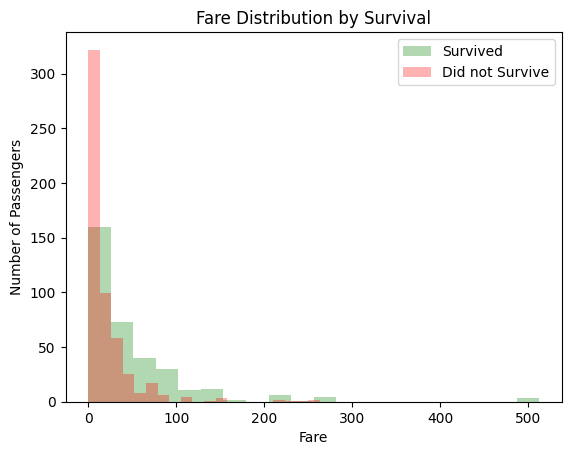

In [17]:
train_df[train_df['Survived'] == 1]['Fare'].hist(alpha=0.3, bins=20, label='Survived', color='green')

train_df[train_df['Survived'] == 0]['Fare'].hist(alpha=0.3, bins=20, label='Did not Survive', color='red')

# Add labels and legend
plt.xlabel('Fare')
plt.ylabel('Number of Passengers')
plt.title('Fare Distribution by Survival')
plt.legend()
plt.grid(False)

# Show the plot
plt.show()

In [18]:
def encode_onehot(_df, _f):
    _df2 = pd.get_dummies(_df[_f], prefix=_f, prefix_sep=' - ', dtype=int)
    _df3 = pd.concat([_df, _df2], axis=1)
    _df3 = _df3.drop([_f], axis=1)
    return _df3

In [19]:
train_df = encode_onehot(train_df, 'Sex')
train_df = encode_onehot(train_df, 'Embarked')
test_df = encode_onehot(test_df, 'Sex')
test_df = encode_onehot(test_df, 'Embarked')

In [20]:
train_df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex - female,Sex - male,Embarked - C,Embarked - Q,Embarked - S
0,0,3,22.0,1,0,7.2500,0,1,0,0,1
1,1,1,38.0,1,0,71.2833,1,0,1,0,0
2,1,3,26.0,0,0,7.9250,1,0,0,0,1
3,1,1,35.0,1,0,53.1000,1,0,0,0,1
4,0,3,35.0,0,0,8.0500,0,1,0,0,1


In [21]:
x = train_df.loc[:, train_df.columns != 'Survived'].values
y = train_df.loc[:, train_df.columns == 'Survived'].values.ravel()

In [22]:
%%time
from sklearn.metrics import accuracy_score
def eval_classifier(_clf, _X, _y, _niter, text=''):
    from sklearn.model_selection import StratifiedKFold
    accs = []
    for i in range(_niter):
        kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=i)
        for train_index, test_index in kf.split(_X, _y):
            _clf.fit(_X[train_index], _y[train_index])
            ypred = _clf.predict(_X[test_index])
            accs += [accuracy_score(_y[test_index], ypred)]

    print(f'{text:<20s} Stratified 10-fold CV acc={np.mean(accs):.3f} with {_niter} iterations')



CPU times: user 1.7 s, sys: 1.02 s, total: 2.72 s
Wall time: 415 ms


In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [24]:
clf =SVC(class_weight='balanced', kernel='rbf', gamma=2, C=2)

In [25]:
eval_classifier(clf,x,y,10, text = 'SVC (rbf)')

SVC (rbf)            Stratified 10-fold CV acc=0.649 with 10 iterations


In [26]:
clf = SVC(class_weight='balanced', kernel='linear', C=2)

In [27]:
eval_classifier(clf,x,y,10, text = 'SVC (linear)')

SVC (linear)         Stratified 10-fold CV acc=0.786 with 10 iterations


In [28]:
clf = GaussianNB()

In [29]:
eval_classifier(clf,x,y,10, text = 'GaussianNB')

GaussianNB           Stratified 10-fold CV acc=0.789 with 10 iterations


In [30]:
clf = RandomForestClassifier()

In [31]:
eval_classifier(clf,x,y,10, text = 'Random Forest')

Random Forest        Stratified 10-fold CV acc=0.813 with 10 iterations


In [32]:
y_pred = clf.predict(test_df) # This is the random forest classifier

/Users/sohumpohane/.pyenv/versions/3.10.14/lib/python3.10/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [33]:
def save_preds(_fn, _y_pred, _df):
    import csv
    with open(_fn, 'w') as fout:
        writer = csv.writer(fout, delimiter=',', lineterminator='\n')
        writer.writerow(['PassengerId', 'Survived'])
        for yid, ypred in zip(_df['PassengerId'], _y_pred):
            writer.writerow([yid, ypred])
save_preds('predictions_pohane.csv', y_pred, test_df_ids)

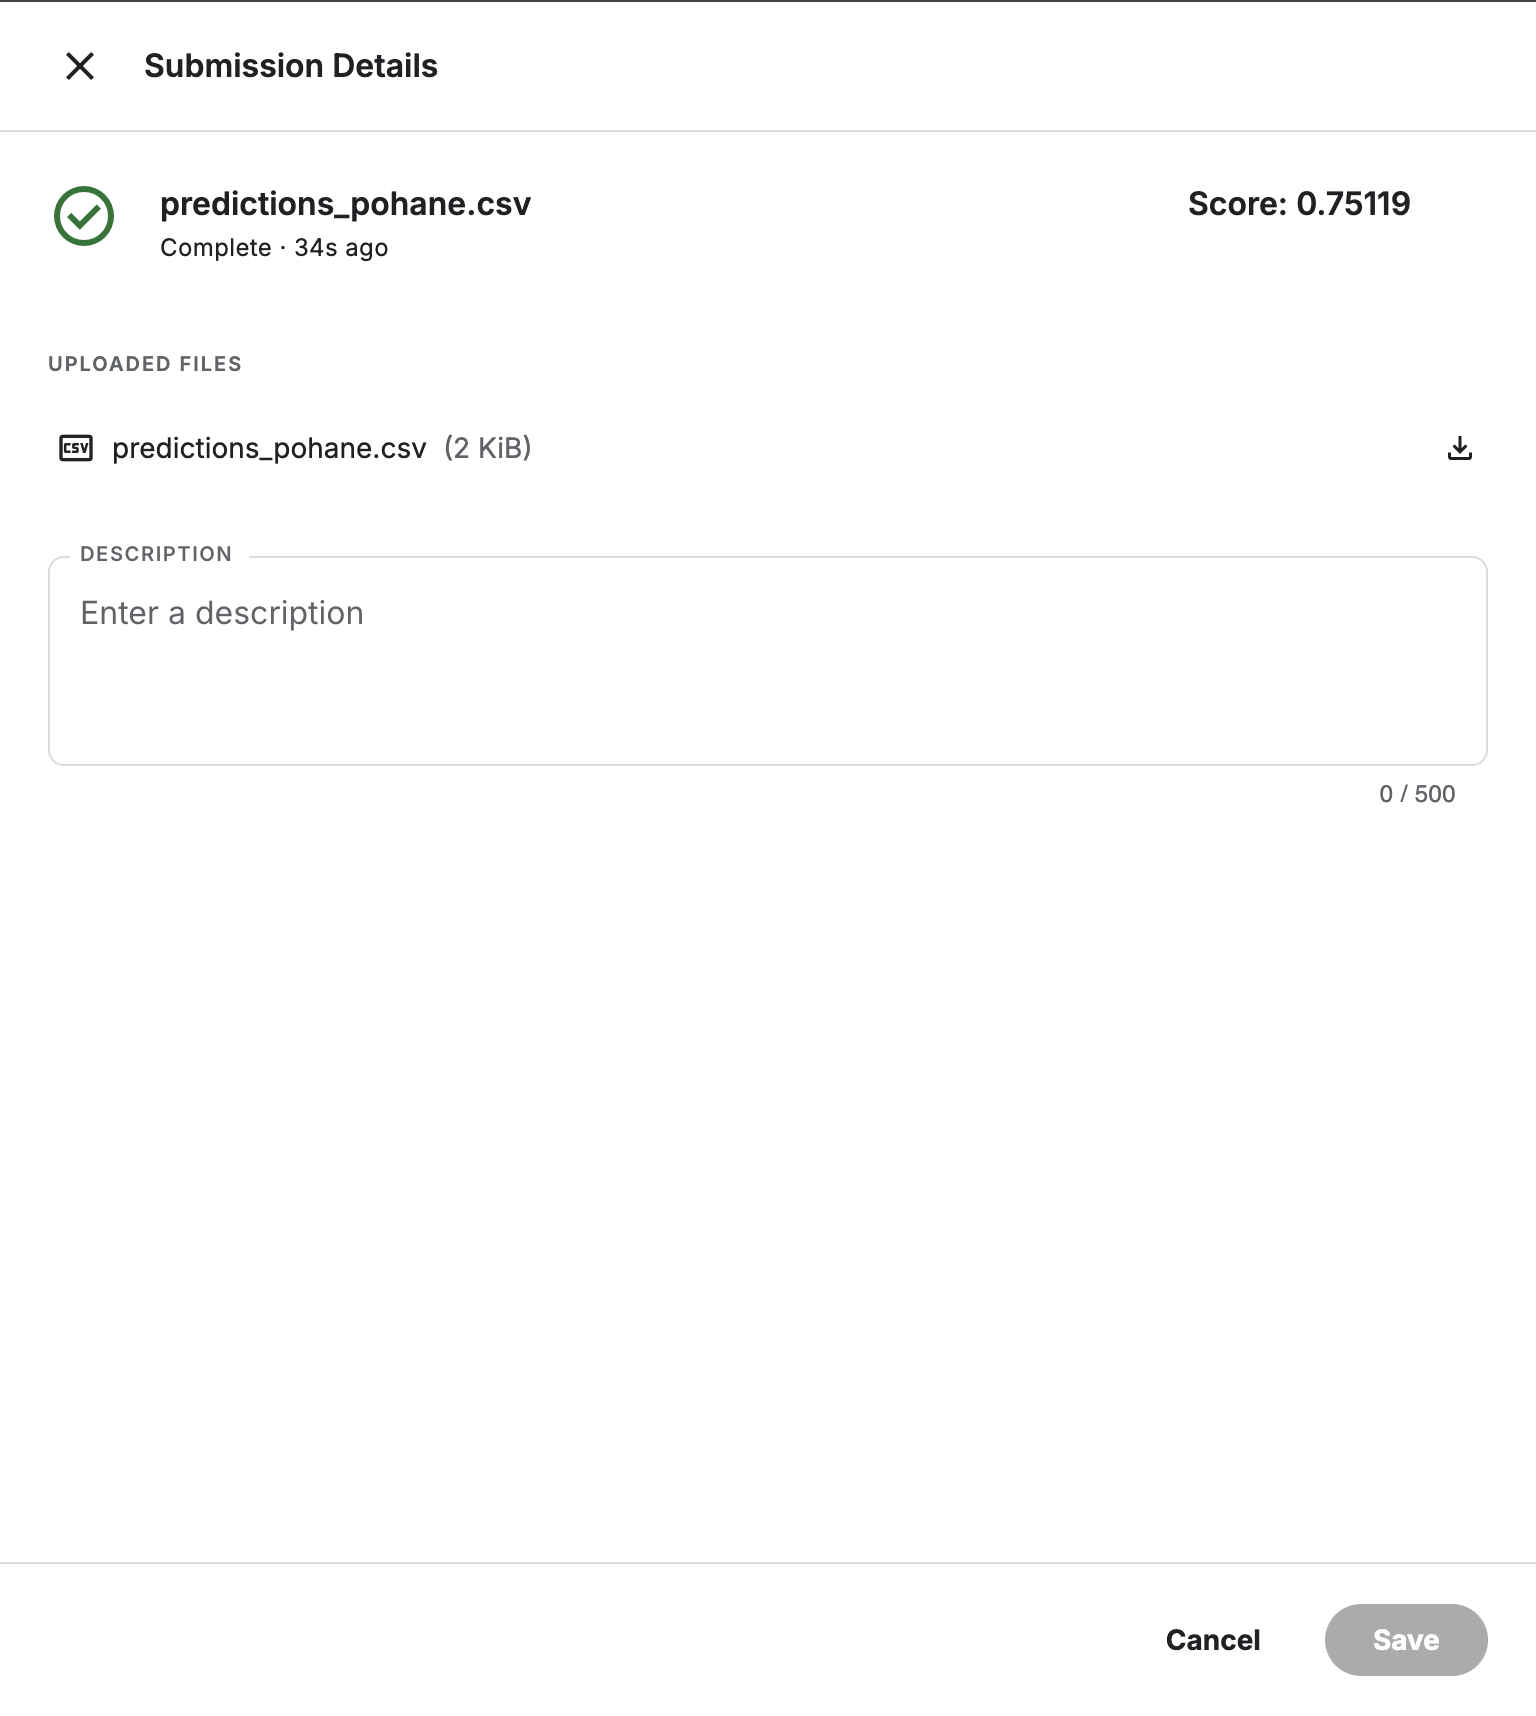